# Ambient Noise Cross-Correlation

<a target="_blank" href="https://colab.research.google.com/github/AI4EPS/EPS130_Seismology/blob/main/notebooks/ambient_noise_lecture.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

Seismologists traditionally rely on earthquakes as seismic sources to image Earth's interior. But what if there are no earthquakes in the region you want to study? **Ambient noise cross-correlation** solves this problem by extracting useful signals from the continuous background vibrations of the Earth — generated by ocean waves, wind, human activity, and other sources.

The key idea: if we cross-correlate long records of ambient noise between two seismic stations, the result approximates the **Green's function** — the signal we would observe at one station if the other were a source. In practice, this recovered signal is dominated by **surface waves** traveling between the two stations.

**In this notebook, you will:**
1. Find seismic stations in a region and compute inter-station distances
2. Download continuous ambient noise recordings
3. Compute cross-correlation functions (CCFs) between station pairs
4. Observe how surface waves emerge from noise cross-correlation
5. See how CCFs vary with distance and recording time

In [1]:
!pip install obspy cartopy -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.signal.cross_correlation import correlate
from obspy.geodetics import locations2degrees, degrees2kilometers

## 1. Find Stations in a Region

We use **Taiwan** for this demonstration — it has a dense broadband seismic network with stations spaced ~20–300 km apart, ideal for ambient noise analysis. Its location between the Philippine Sea and Eurasian plates also means strong ocean-generated noise from multiple directions.

We query the FDSN web service for stations with broadband (BH) channels, which record in the frequency range where ambient noise is strongest (~0.05–1 Hz).

In [3]:
# Connect to FDSN data center
client = Client("IRIS")

# Query broadband stations in Taiwan
inventory = client.get_stations(
    minlatitude=22.1, maxlatitude=26.0,
    minlongitude=119.6, maxlongitude=121.8,
    starttime=UTCDateTime("2020-01-01"),
    endtime=UTCDateTime("2020-01-02"),
    channel="BH*",
    level="station",
)

# Store station names and coordinates
stations = {}
for network in inventory:
    for station in network:
        name = f"{network.code}.{station.code}"
        stations[name] = (station.latitude, station.longitude)

print(f"Found {len(stations)} stations:")
for name, (lat, lon) in stations.items():
    print(f"  {name}  ({lat:.2f}\u00b0N, {lon:.2f}\u00b0E)")

Found 13 stations:
  IU.TATO  (24.97°N, 121.50°E)
  TW.CHGB  (24.06°N, 121.17°E)
  TW.HGSD  (23.49°N, 121.42°E)
  TW.NACB  (24.17°N, 121.59°E)
  TW.RLNB  (23.89°N, 120.36°E)
  TW.SSLB  (23.79°N, 120.95°E)
  TW.TATO  (24.98°N, 121.49°E)
  TW.TDCB  (24.25°N, 121.16°E)
  TW.TPUB  (23.30°N, 120.63°E)
  TW.TWGB  (22.82°N, 121.08°E)
  TW.WFSB  (25.07°N, 121.78°E)
  TW.YHNB  (24.67°N, 121.38°E)
  TW.YULB  (23.39°N, 121.30°E)


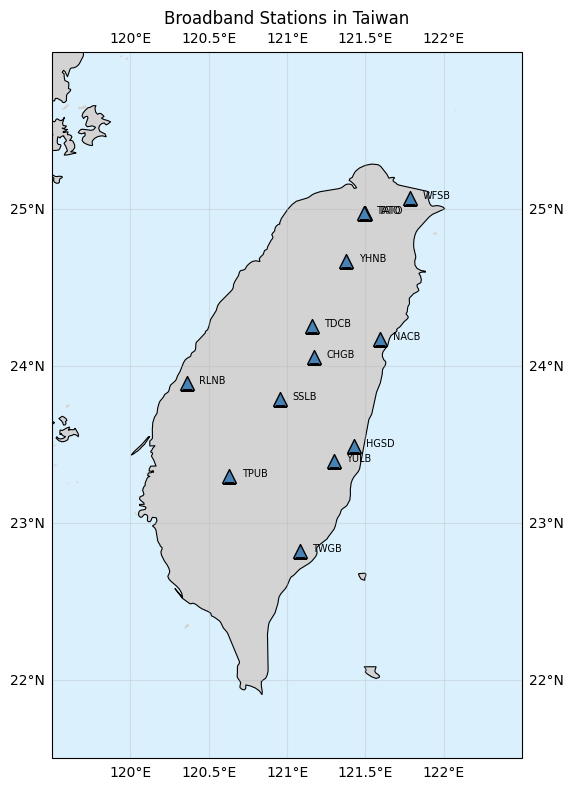

In [4]:
fig = plt.figure(figsize=(6, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([119.5, 122.5, 21.5, 26.0], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightskyblue', alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.gridlines(draw_labels=True, alpha=0.3)

# Plot stations
for name, (lat, lon) in stations.items():
    ax.plot(lon, lat, '^', color='steelblue', markersize=10,
            markeredgecolor='k', transform=ccrs.PlateCarree())
    ax.text(lon + 0.08, lat, name.split('.')[1], fontsize=7,
            transform=ccrs.PlateCarree())

ax.set_title('Broadband Stations in Taiwan')
plt.tight_layout()
plt.show()

## 2. Station Pair Distances

The inter-station distance determines where the surface wave signal appears in the cross-correlation function:

$$\tau_{\text{arrival}} = \frac{D}{c}$$

- $D$: inter-station distance
- $c$: surface wave speed (~2–4 km/s)
- $\tau_{\text{arrival}}$: expected lag time in the CCF

Let's compute all pairwise distances and pick station pairs for the next steps.

In [5]:
# Compute distances for the station pairs we will use later
pairs = [
    ("TW.NACB", "TW.YHNB"),
    ("TW.SSLB", "TW.TPUB"),
    ("TW.TPUB", "TW.YULB"),
    ("TW.NACB", "TW.SSLB"),
    ("TW.NACB", "TW.YULB"),
    ("TW.SSLB", "TW.YHNB"),
    ("TW.SSLB", "TW.TWGB"),
    ("TW.NACB", "TW.TPUB"),
]

for s1, s2 in pairs:
    lat1, lon1 = stations[s1]
    lat2, lon2 = stations[s2]
    dist = degrees2kilometers(locations2degrees(lat1, lon1, lat2, lon2))
    print(f"  {s1} — {s2}: {dist:6.1f} km")

  TW.NACB — TW.YHNB:   59.4 km
  TW.SSLB — TW.TPUB:   63.5 km
  TW.TPUB — TW.YULB:   68.9 km
  TW.NACB — TW.SSLB:   78.0 km
  TW.NACB — TW.YULB:   92.0 km
  TW.SSLB — TW.YHNB:  107.0 km
  TW.SSLB — TW.TWGB:  108.6 km
  TW.NACB — TW.TPUB:  138.1 km


## 3. Download Ambient Noise for a Station Pair

Let's pick two stations and download one day of vertical-component (BHZ) data. We'll use this to demonstrate cross-correlation step by step.

_Try changing the channel component (BHE, BHN instead of BHZ) — how do the results differ?_

In [6]:
# Pick a station pair
sta1, sta2 = "TW.NACB", "TW.YHNB"

# Download one day of vertical-component data
starttime = UTCDateTime("2020-01-01")
endtime = UTCDateTime("2020-01-02")

net1, name1 = sta1.split(".")
net2, name2 = sta2.split(".")
st1 = client.get_waveforms(net1, name1, "", "BHZ", starttime, endtime)
st2 = client.get_waveforms(net2, name2, "", "BHZ", starttime, endtime)

print(f"Station 1: {st1[0]}")
print(f"Station 2: {st2[0]}")

Station 1: TW.NACB..BHZ | 2020-01-01T00:00:00.019500Z - 2020-01-01T23:59:59.977740Z | 20.0 Hz, 1728000 samples
Station 2: TW.YHNB..BHZ | 2020-01-01T00:00:00.019500Z - 2020-01-01T23:59:59.985979Z | 20.0 Hz, 1728000 samples


At first glance, the recordings at both stations look like random noise. There's no obvious earthquake signal — just continuous background vibrations. Can we extract anything useful from this?

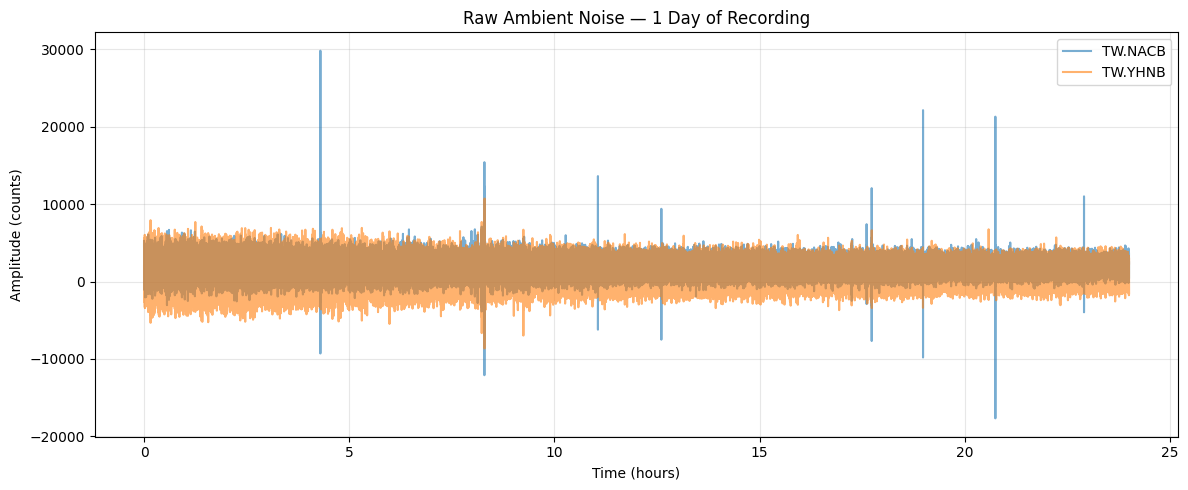

In [7]:
# Plot 24 hours of raw ambient noise
sr = st1[0].stats.sampling_rate
time1 = np.arange(st1[0].stats.npts) / sr / 3600  # convert to hours
time2 = np.arange(st2[0].stats.npts) / sr / 3600

plt.figure(figsize=(12, 5))
plt.plot(time1, st1[0].data, label=sta1, alpha=0.6)
plt.plot(time2, st2[0].data, label=sta2, alpha=0.6)
plt.xlabel('Time (hours)')
plt.ylabel('Amplitude (counts)')
plt.title('Raw Ambient Noise \u2014 1 Day of Recording')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Cross-Correlation

**What is cross-correlation?** It measures the similarity between two signals as a function of a time shift (lag):

$$C_{AB}(\tau) = \int u_A(t) \, u_B(t + \tau) \, dt$$

**Why does this work for ambient noise?** Imagine ocean waves generating seismic noise from all directions. Some noise travels from station A to station B with a time delay $\tau = D/c$. When we cross-correlate long records, these coherent arrivals add up while random noise cancels out. The result looks like a **surface wave** traveling between the stations.

**Interpreting the CCF:**
- **Positive lag** ($\tau > 0$): waves traveling from station 1 $\to$ station 2
- **Negative lag** ($\tau < 0$): waves traveling from station 2 $\to$ station 1
- If noise sources are evenly distributed, the CCF is roughly **symmetric**
- If noise comes mainly from one direction, one side is stronger

Let's preprocess the data and compute the cross-correlation step by step.

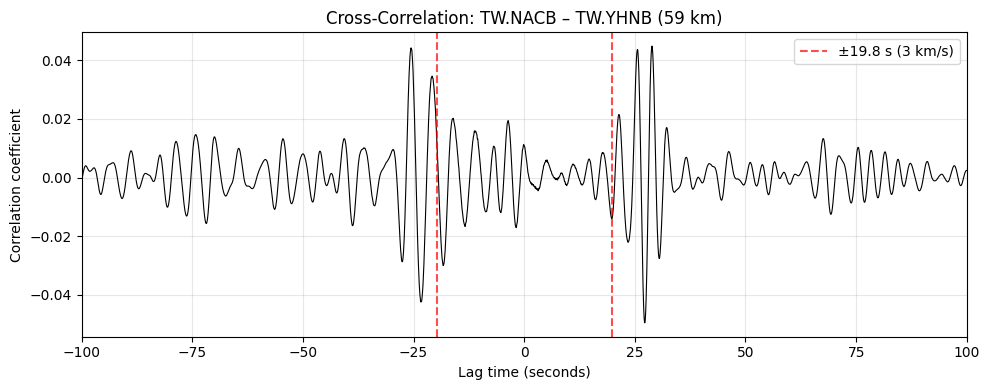

In [8]:
# Copy traces so we can re-use the originals later
tr1 = st1[0].copy()
tr2 = st2[0].copy()

# Preprocessing
for tr in [tr1, tr2]:
    tr.detrend("demean")   # remove DC offset so signal centers on zero
    tr.detrend("linear")   # remove slow instrumental drift
    tr.taper(0.05)          # smooth edges to zero to prevent spectral artifacts

# Trim to common time window
t_start = max(tr1.stats.starttime, tr2.stats.starttime)
t_end = min(tr1.stats.endtime, tr2.stats.endtime)
tr1.trim(t_start, t_end)
tr2.trim(t_start, t_end)

# Cross-correlate (max lag = 300 seconds)
max_lag = 300
shift = int(tr1.stats.sampling_rate * max_lag)
ccf = correlate(tr1.data, tr2.data, shift=shift, normalize='naive')  # normalize by signal energy
lags = np.arange(-shift, shift + 1) / tr1.stats.sampling_rate

# Inter-station distance
lat1, lon1 = stations[sta1]
lat2, lon2 = stations[sta2]
dist_km = degrees2kilometers(locations2degrees(lat1, lon1, lat2, lon2))

# Plot
plt.figure(figsize=(10, 4))
plt.plot(lags, ccf, 'k', lw=0.8)

# Mark expected surface wave arrival (~3 km/s)
t_arrival = dist_km / 3.0
plt.axvline(t_arrival, color='r', ls='--', alpha=0.7,
            label=f'\u00b1{t_arrival:.1f} s (3 km/s)')
plt.axvline(-t_arrival, color='r', ls='--', alpha=0.7)

plt.title(f'Cross-Correlation: {sta1} \u2013 {sta2} ({dist_km:.0f} km)')
plt.xlabel('Lag time (seconds)')
plt.ylabel('Correlation coefficient')
plt.xlim(-100, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Cross-Correlations at Different Distances

Now let's compute CCFs for multiple station pairs at different distances. If the signal in the CCF is a real surface wave, its arrival time should scale linearly with distance: $\tau = D/c$.

We'll plot the CCFs stacked by distance, with reference moveout lines.

_Some pairs may show stronger signal on one side — what does that tell you about the noise source direction? Taiwan faces the Pacific Ocean to the east, so ocean-generated microseism noise arrives preferentially from that direction, which can make the CCF asymmetric._

In [9]:
def download_and_correlate(sta1, sta2, starttime, endtime, max_lag=300):
    """Download noise for two stations, preprocess, and cross-correlate."""
    net1, name1 = sta1.split(".")
    net2, name2 = sta2.split(".")

    st1 = client.get_waveforms(net1, name1, "", "BHZ", starttime, endtime)
    st2 = client.get_waveforms(net2, name2, "", "BHZ", starttime, endtime)

    tr1 = st1[0].copy()
    tr2 = st2[0].copy()

    for tr in [tr1, tr2]:
        tr.detrend("demean")
        tr.detrend("linear")
        tr.taper(0.05)

    # Resample if sampling rates differ
    if tr1.stats.sampling_rate != tr2.stats.sampling_rate:
        tr2.resample(tr1.stats.sampling_rate)

    # Trim to common time window
    t1 = max(tr1.stats.starttime, tr2.stats.starttime)
    t2 = min(tr1.stats.endtime, tr2.stats.endtime)
    tr1.trim(t1, t2)
    tr2.trim(t1, t2)

    # Cross-correlate
    shift = int(tr1.stats.sampling_rate * max_lag)
    ccf = correlate(tr1.data, tr2.data, shift=shift, normalize='naive')
    lags = np.arange(-shift, shift + 1) / tr1.stats.sampling_rate

    # Distance
    lat1, lon1 = stations[sta1]
    lat2, lon2 = stations[sta2]
    dist = degrees2kilometers(locations2degrees(lat1, lon1, lat2, lon2))

    return lags, ccf, dist

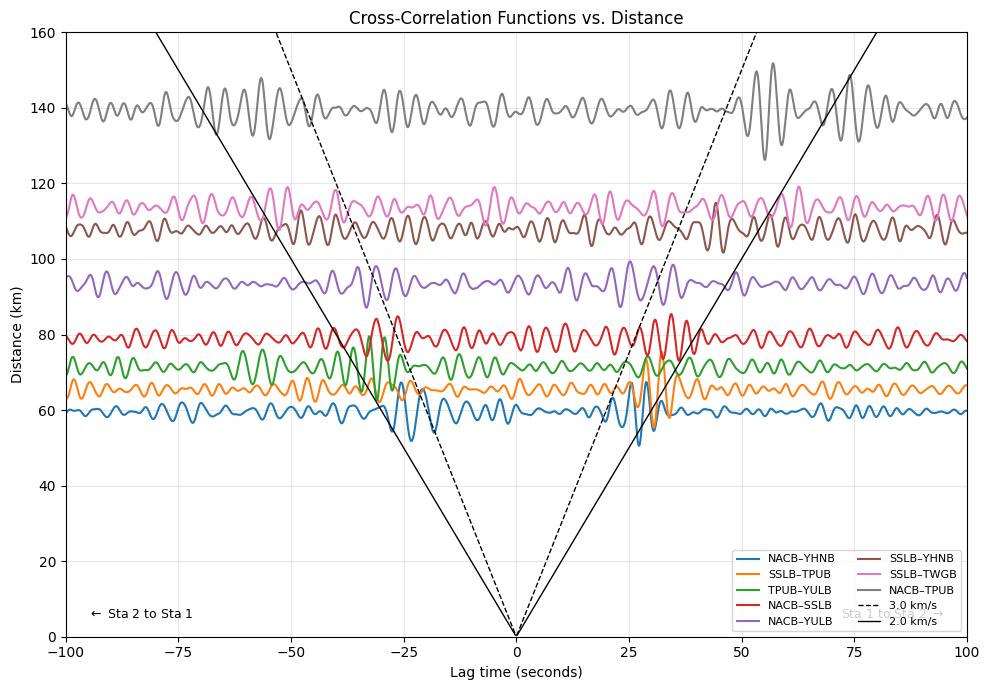

In [10]:
# Station pairs at various distances
pairs = [
    ("TW.NACB", "TW.YHNB"),
    ("TW.SSLB", "TW.TPUB"),
    ("TW.TPUB", "TW.YULB"),
    ("TW.NACB", "TW.SSLB"),
    ("TW.NACB", "TW.YULB"),
    ("TW.SSLB", "TW.YHNB"),
    ("TW.SSLB", "TW.TWGB"),
    ("TW.NACB", "TW.TPUB"),
]

starttime = UTCDateTime("2020-01-01")
endtime = UTCDateTime("2020-01-02")

plt.figure(figsize=(10, 7))
for s1, s2 in pairs:
    lags, ccf, dist = download_and_correlate(s1, s2, starttime, endtime)
    n1, n2 = s1.split(".")[1], s2.split(".")[1]
    plt.plot(lags, ccf * 3 * dist + dist, label=f"{n1}–{n2}")

# Reference moveout lines for surface wave speeds
t = np.linspace(-100, 100, 500)
plt.plot(t, np.abs(3.0 * t), 'k--', lw=1, label='3.0 km/s')
plt.plot(t, np.abs(2.0 * t), 'k-', lw=1, label='2.0 km/s')

plt.title('Cross-Correlation Functions vs. Distance')
plt.xlabel('Lag time (seconds)')
plt.ylabel('Distance (km)')
plt.text(-95, 5, r'$\leftarrow$ Sta 2 to Sta 1', fontsize=9, ha='left')
plt.text(95, 5, r'Sta 1 to Sta 2 $\rightarrow$', fontsize=9, ha='right')
plt.xlim(-100, 100)
plt.ylim(0, 160)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## 6. How CCFs Change with Time

Let's split the day into overlapping 3-hour windows and compute a CCF for each one. Individual windows are noisy, but the surface wave signal is visible in most of them. Stacking many windows would improve the signal — this is why ambient noise studies typically use weeks to months of data. (One day is enough for a demo, but published studies often stack 6–12 months for high-quality measurements.)

_What do you think drives the differences between windows? Try changing the window length — how does that affect the results?_

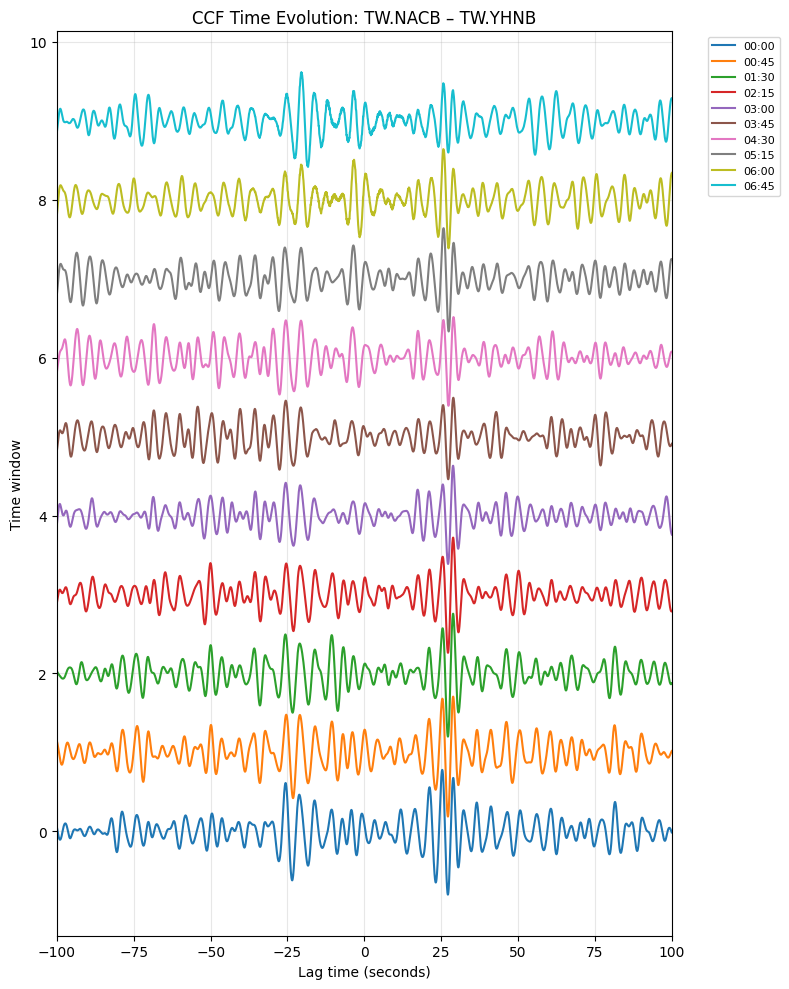

In [11]:
sta1, sta2 = "TW.NACB", "TW.YHNB"
starttime = UTCDateTime("2020-01-01")
window_length = 10800  # 3 hours (seconds)
n_windows = 10

plt.figure(figsize=(8, 10))
for i in range(n_windows):
    t1 = starttime + i * window_length // 4  # 75% overlap
    t2 = t1 + window_length

    lags, ccf, dist = download_and_correlate(sta1, sta2, t1, t2)
    plt.plot(lags, ccf * 10 + i, label=t1.strftime("%H:%M"))

plt.title(f'CCF Time Evolution: {sta1} \u2013 {sta2}')
plt.xlabel('Lag time (seconds)')
plt.ylabel('Time window')
plt.xlim(-100, 100)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

---
## Summary

**Key takeaways:**

1. **Ambient noise is not random** — it contains coherent surface waves generated by ocean waves, wind, and human activity.

2. **Cross-correlation recovers surface waves** — by cross-correlating noise between two stations, we extract the surface wave Green's function, as if one station were a seismic source.

3. **Arrival time scales with distance** — the signal arrives at lag time $\tau \approx D/c$, where $D$ is the inter-station distance and $c \approx 2$–$4$ km/s for surface waves.

4. **Longer stacking improves signal** — individual short-window CCFs are noisy, but stacking over days to months produces clear, stable signals.

5. **Asymmetry reveals noise source direction** — if noise comes mainly from one direction, the CCF is stronger on one side (causal vs. acausal).

**Connection to other topics:** The surface wave travel times from ambient noise CCFs can be used for **seismic tomography** — mapping the velocity structure of the crust and upper mantle without needing earthquakes.